# Lecture 04 — Online-store accessory suggestions

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Association rule mining · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Learn transparent accessory suggestions from synthetic purchase baskets.

## Practical problem
An imaginary electronics shop analyses co-purchases to propose related accessories.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** The examples are artificial and exclude stock availability, compatibility and price.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 620 rows × 9 columns


,laptop,mouse,keyboard,headphones,tablet,case,charger,webcam,transaction_id
0,0,0,0,0,1,1,1,0,1
1,0,1,0,0,0,0,0,0,2
2,0,0,0,0,0,1,1,0,3
3,1,0,0,0,0,0,0,0,4
4,0,1,0,1,0,0,1,0,5


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['laptop', 'mouse', 'keyboard', 'headphones', 'tablet', 'case', 'charger', 'webcam', 'transaction_id']
Missing values per column:
laptop            0
mouse             0
keyboard          0
headphones        0
tablet            0
case              0
charger           0
webcam            0
transaction_id    0


## 2. Visualise purchase patterns
Transactions are represented by zeros and ones: 1 means the item was observed in the basket. No product is a supervised class label.

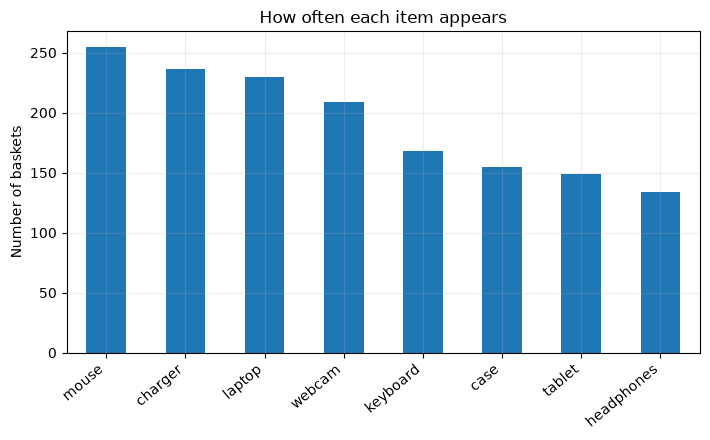

Example baskets:
1 ['tablet', 'case', 'charger']
2 ['mouse']
3 ['case', 'charger']
4 ['laptop']
5 ['mouse', 'headphones', 'charger']


In [3]:
items=[c for c in df.columns if c!='transaction_id']
counts=df[items].sum().sort_values(ascending=False)
counts.plot.bar(title='How often each item appears',ylabel='Number of baskets');plt.xticks(rotation=40,ha='right');plt.tight_layout();plt.show()
print('Example baskets:')
for _,r in df.head(5).iterrows():
 print(int(r['transaction_id']),[i for i in items if r[i]==1])

## 3. Derive association rules (one antecedent item → one consequent item)
**Support** = proportion of all baskets containing both items. **Confidence** = proportion containing B among baskets containing A. **Lift** = confidence divided by the overall frequency of B; lift above 1 indicates positive association. Association rules are descriptive; they do not prove causation.

In [4]:
from itertools import permutations
items=[c for c in df.columns if c!='transaction_id']
N=len(df)
# Simple pedagogical implementation of one-item => one-item association rules.
rows=[]
for left,right in permutations(items,2):
    pa=df[left].mean();pb=df[right].mean()
    pab=((df[left]==1)&(df[right]==1)).mean()
    if pa==0 or pb==0: continue
    confidence=pab/pa
    lift=confidence/pb
    rows.append({'if_bought':left,'then_recommend':right,'support':pab,'confidence':confidence,'lift':lift})
rules=pd.DataFrame(rows)
strong=rules.query('support >= .10 and confidence >= .30').sort_values(['lift','confidence'],ascending=False)
print(f'{len(strong)} filtered rules from {N} orders')
display(strong.head(12).round(3))

23 filtered rules from 620 orders


,if_bought,then_recommend,support,confidence,lift
32,tablet,case,0.142,0.591,2.362
39,case,tablet,0.142,0.568,2.362
27,headphones,webcam,0.124,0.575,1.705
52,webcam,headphones,0.124,0.368,1.705
14,keyboard,laptop,0.147,0.542,1.460
1,laptop,keyboard,0.147,0.396,1.460
40,case,charger,0.137,0.548,1.441
47,charger,case,0.137,0.360,1.441
46,charger,tablet,0.131,0.343,1.428
33,tablet,charger,0.131,0.544,1.428


## 4. Plot the discovered rules
A strong rule should have useful support as well as lift: an apparently enormous lift from a very rare combination may not generalise.

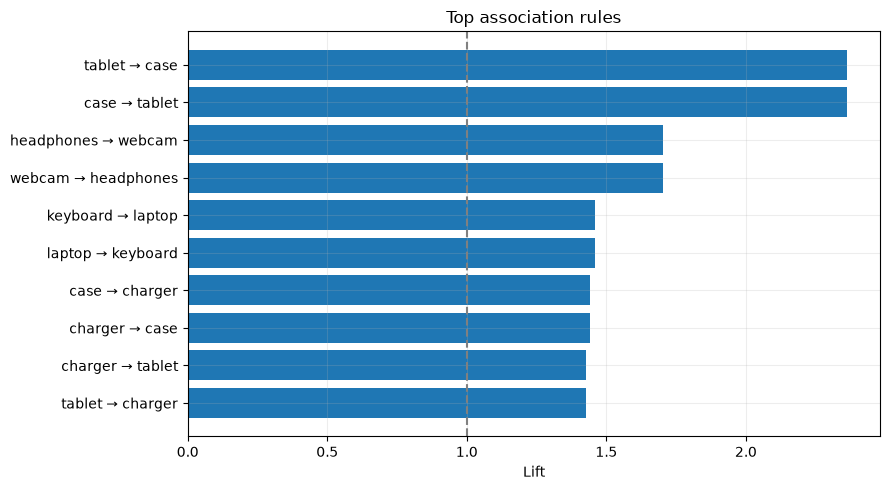

In [5]:
top=strong.head(10).copy()
if top.empty: top=rules.sort_values('lift',ascending=False).head(10)
top['rule']=top['if_bought']+' → '+top['then_recommend']
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(top['rule'].iloc[::-1],top['lift'].iloc[::-1]);ax.axvline(1,linestyle='--',color='gray')
ax.set(xlabel='Lift',title='Top association rules');plt.tight_layout();plt.show()

## 5. Make a rule-based suggestion for a new basket
This is an association-rule recommender: the recommendation is the consequent of the strongest matching rule, not a trained classification label. Consumers have different needs; co-purchases are not necessarily preferences.

In [6]:
cart=['laptop']
options=strong[(strong['if_bought'].isin(cart)) & (~strong['then_recommend'].isin(cart))].copy()
print('Current basket:',cart)
if len(options):
 best=options.iloc[0]
 print(f"Suggested item: {best['then_recommend']} (confidence={best['confidence']:.1%}, lift={best['lift']:.2f})")
else: print('No suitable rule at the chosen support/confidence threshold.')

Current basket: ['laptop']
Suggested item: keyboard (confidence=39.6%, lift=1.46)


## 6. Evaluation appropriate to association rules
Report **support, confidence, and lift**, and optionally validate held-out baskets. **Accuracy, precision, recall and confusion matrices** are not the general measures for an unsupervised association-rule discovery task; they would require defining a separate prediction target and evaluation protocol.

## Student investigation and discussion
1. Why do support and lift tell different stories?
2. What additional data would be required for product compatibility?
3. What is the difference between rule discovery and personalised recommendation?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.